# <b>공모전 제출 파일

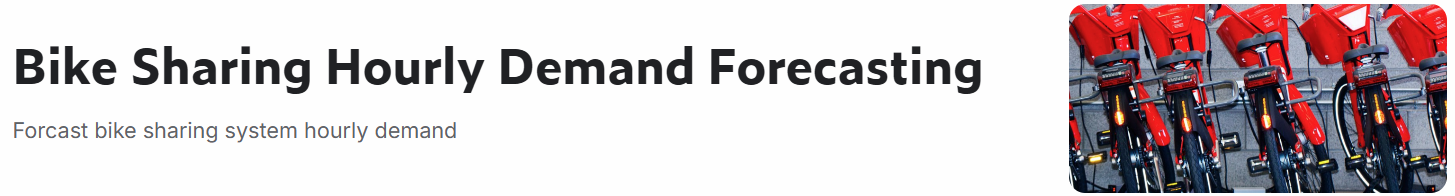
* kaggle : https://www.kaggle.com/competitions/bike-sharing-demand

In [1]:
from sklearn import set_config
set_config(display="text")
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split                           #---- 문제답 분리
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor   #---- 회귀모델(트리모델)   

from sklearn.metrics import root_mean_squared_log_error                        #---- 평가 메트릭스
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler   #----정규화(스케일링)

# **[1] Data Load**

In [2]:
train = pd.read_csv("../datas/bike/train.csv", parse_dates=['datetime'])
test  = pd.read_csv("../datas/bike/test.csv" , parse_dates=['datetime'])
sub   = pd.read_csv("../datas/bike/sampleSubmission.csv")

In [3]:
train.shape, test.shape, sub.shape

((10886, 12), (6493, 9), (6493, 2))

In [4]:
train.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40


In [5]:
test.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000


In [6]:
sub.head(2)

,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [8]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    6493 non-null   datetime64[us]
 1   season      6493 non-null   int64         
 2   holiday     6493 non-null   int64         
 3   workingday  6493 non-null   int64         
 4   weather     6493 non-null   int64         
 5   temp        6493 non-null   float64       
 6   atemp       6493 non-null   float64       
 7   humidity    6493 non-null   int64         
 8   windspeed   6493 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(5)
memory usage: 456.7 KB


* <font color=red><b>결측없다
* <font color=red><b>글자있다 --> datetime --> 년월일시로 분리

## 년월일시 분리

In [9]:
train['yy']   = train['datetime'].dt.year
train['mm']   = train['datetime'].dt.month
train['dd']   = train['datetime'].dt.day
train['hh']   = train['datetime'].dt.hour
train['week'] = train['datetime'].dt.weekday             #월요일~일요일  : 0~6
#train['date'] = train['datetime'].dt.date               #------전체날짜
train['woy']  = train['datetime'].dt.isocalendar().week  #------몇주차

test['yy']    = test['datetime'].dt.year
test['mm']    = test['datetime'].dt.month
test['dd']    = test['datetime'].dt.day
test['hh']    = test['datetime'].dt.hour
test['week']  = test['datetime'].dt.weekday             #월요일~일요일  : 0~6
#test['date']  = test['datetime'].dt.date               #------전체날짜
test['woy']   = test['datetime'].dt.isocalendar().week  #------몇주차

## 달력 공휴일 추가

In [10]:
dates = [
    (pd.Timestamp(2011, 4, 15), 1, 0),   # Tax day
    (pd.Timestamp(2012, 4, 16), 1, 0),   # Tax day
    (pd.Timestamp(2011, 11, 25), 0, 1),  # Thanksgiving Friday
    (pd.Timestamp(2012, 11, 23), 0, 1),  # Thanksgiving Friday
    (pd.Timestamp(2011, 12, 24), 0, 1),  # Christmas
    (pd.Timestamp(2012, 12, 24), 0, 1),  # Christmas
    (pd.Timestamp(2011, 12, 26), 0, 1),  # Christmas
    (pd.Timestamp(2012, 12, 26), 0, 1),  # Christmas
    (pd.Timestamp(2011, 12, 31), 0, 1),  # New Year's Eve
    (pd.Timestamp(2012, 12, 31), 0, 1),  # New Year's Eve
    (pd.Timestamp(2012, 5, 21), 0, 1),   # Storms
    (pd.Timestamp(2012, 6, 1), 0, 1),    # Tornado
    (pd.Timestamp(2012, 10, 30), 0, 1),  # Sandy
]

In [11]:
for date, workingday_value, holiday_value in dates:
    train.loc[train['datetime'].dt.date == date.date(),'workingday'] = workingday_value
    train.loc[train['datetime'].dt.date == date.date(),'holiday'] = holiday_value

for date, workingday_value, holiday_value in dates:
    test.loc[test['datetime'].dt.date == date.date(),'workingday'] = workingday_value
    test.loc[test['datetime'].dt.date == date.date(),'holiday'] = holiday_value    

## datetime 인덱스로 빼기

In [12]:
train = train.set_index("datetime")
test  = test.set_index("datetime")

In [13]:
train.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,dd,hh,week,woy
datetime,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5,52
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5,52


In [14]:
test.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,dd,hh,week,woy
datetime,,,,,,,,,,,,,,
2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0,3,3
2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,1,3,3


# **[2] EDA(Exploratory Data Analysis)**

## hist() : 데이터 분포도(왜도,첨도,정규분포)

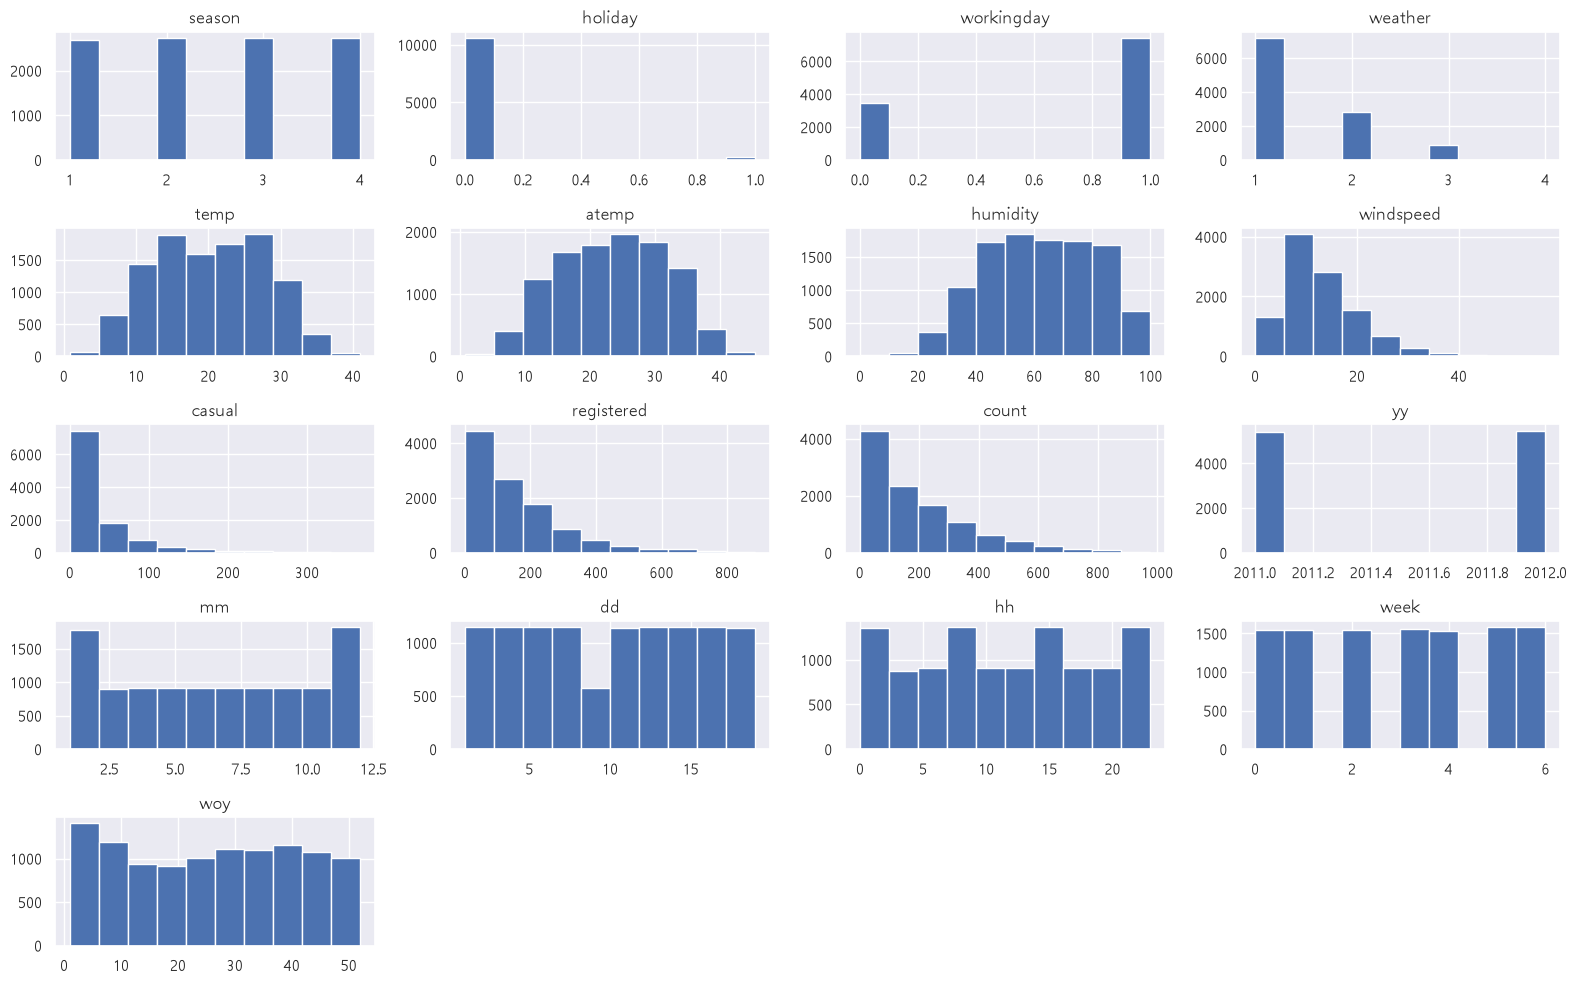

In [15]:
train.hist(figsize=(16,10))
plt.tight_layout()
plt.show()

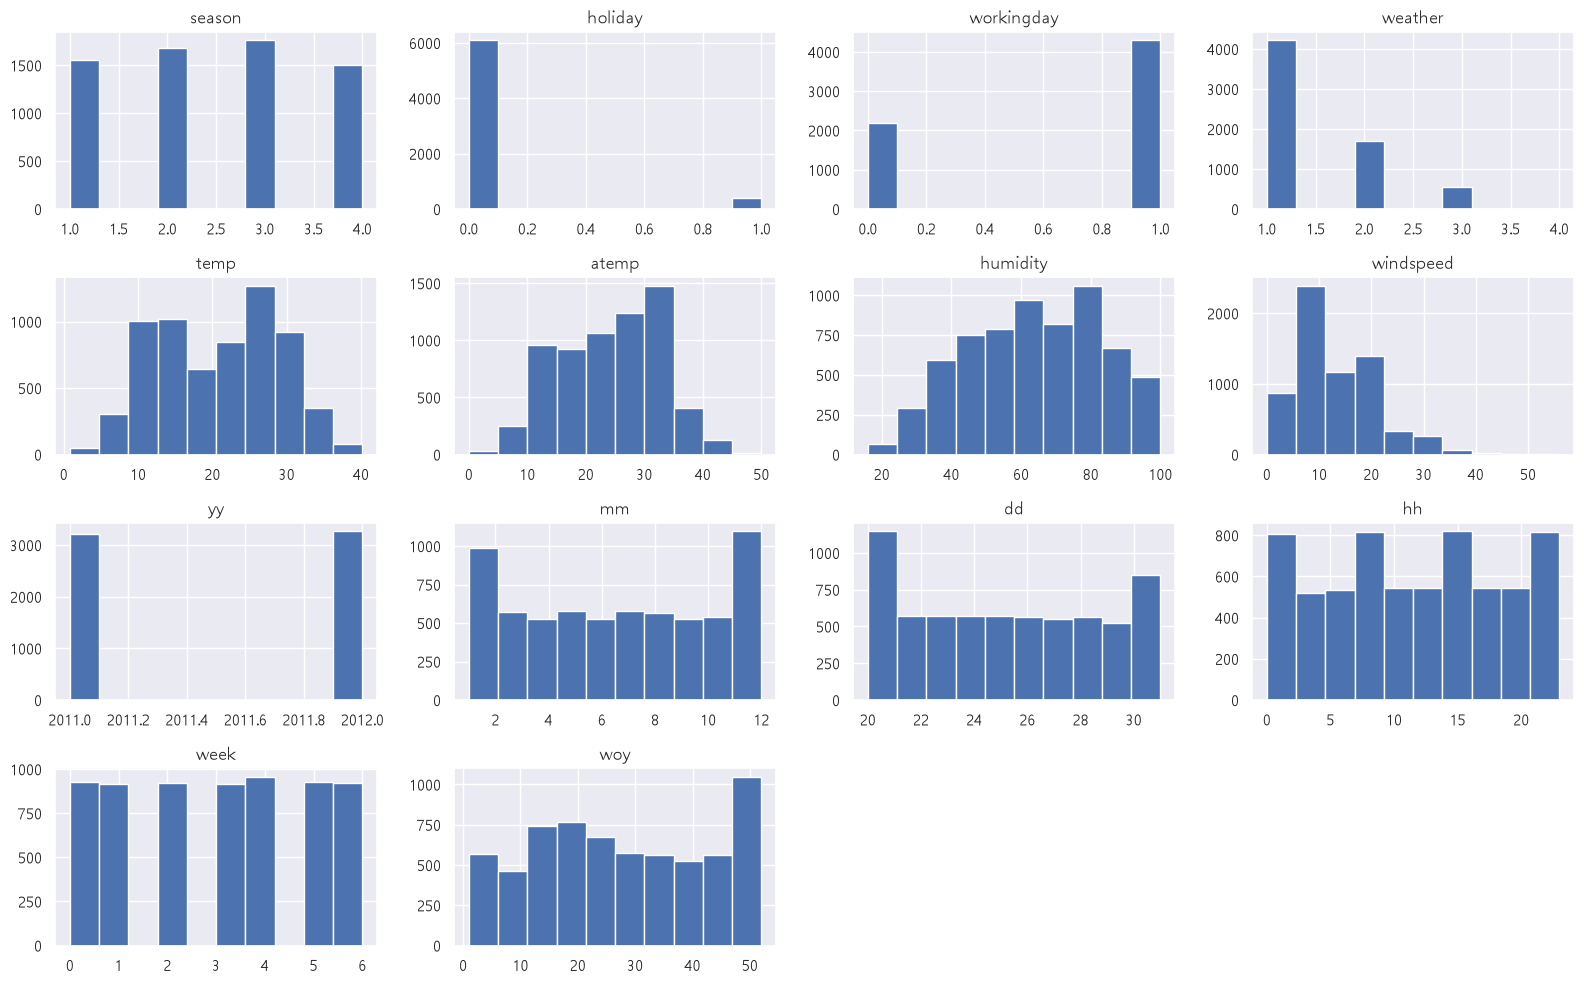

In [16]:
test.hist(figsize=(16,10))
plt.tight_layout()
plt.show()

## **상관분석**

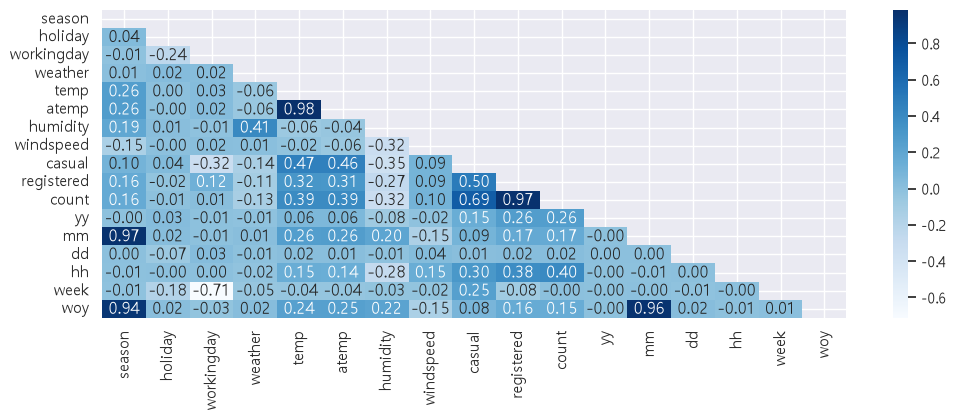

In [17]:
plt.figure(figsize=(12, 4))
# 위쪽 삼각형 가리기
mask = np.triu(np.ones_like(train.corr(), dtype=bool))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="Blues", mask=mask)
plt.show()

* mm - season : 0.97  ----------------------- 다중공선 - 필요시 파생피쳐는 삭제
* week - workingday : -0.70  ---------------- 다중공선 - 필요시 파생피쳐는 삭제
* atemp - temp : 0.98  --> 대여수 영향 큼
* casual + registered = count : 0.97

<pre>
- 날짜 : 'yy', 'mm', 'hh', 'season'
- 날씨 : 'weather', 'temp', 'atemp','humidity', 'windspeed'
- 타켓 : 'casual', 'registered', 'count' 
- 휴일 : 'holiday', 'workingday', 'week'

## 날짜 관련
* 계절 : 'yy', 'mm', 'hh', 'season'

### 년별, 월별, 시간별, 계절별 대여수

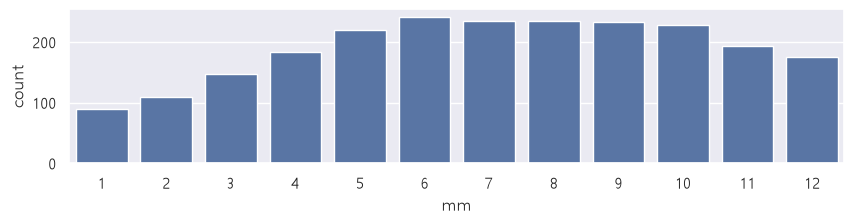

In [18]:
plt.figure(figsize=(10, 2))
sns.barplot(x="mm", y="count", data=train, errorbar=None)  #errorbar=('ci', 95)
plt.show()

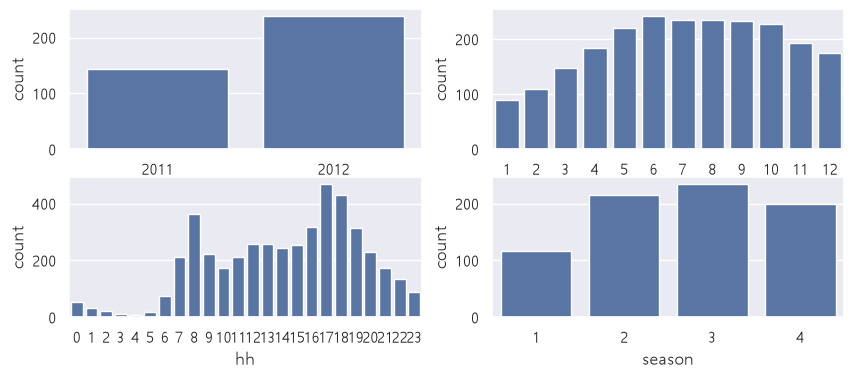

In [19]:
plt.figure(figsize=(10, 4)) 

plt.subplot(2,2,      1)         #---------------------------2행2열의 1번째
sns.barplot(x="yy", y="count", data=train, errorbar=None) 

plt.subplot(2,2,      2)         #---------------------------2행2열의 2번째
sns.barplot(x="mm", y="count", data=train, errorbar=None) 

plt.subplot(2,2,      3)         #---------------------------2행2열의 3번째
sns.barplot(x="hh", y="count", data=train, errorbar=None) 

plt.subplot(2,2,      4)         #---------------------------2행2열의 4번째
sns.barplot(x="season", y="count", data=train, errorbar=None) 

plt.show()

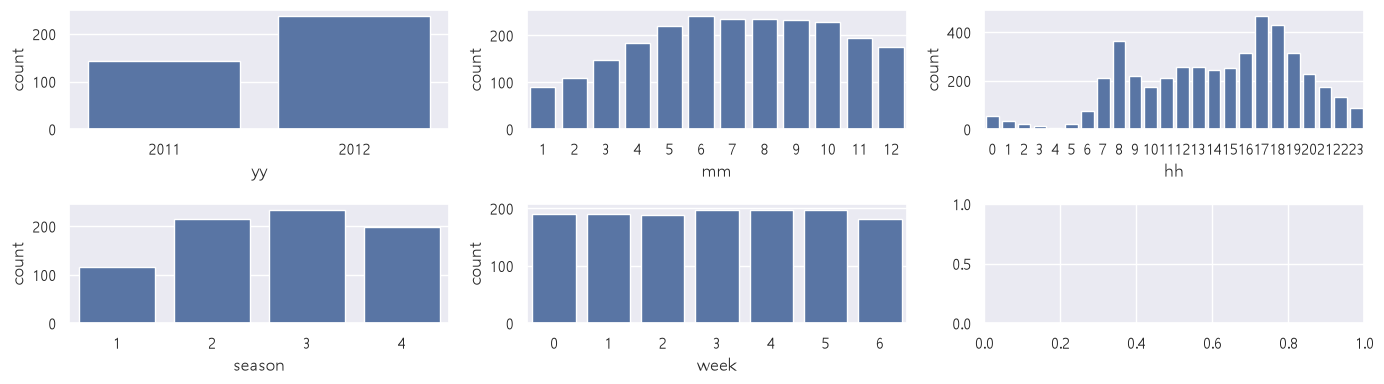

In [20]:
fig, axes = plt.subplots(2,3,     figsize=(14, 4)) 
col_list=['yy', 'mm', 'hh', 'season', 'week']

for i, col in enumerate(col_list) :
    줄=i//3
    칸=i%3
    sns.barplot(x=col, y="count", data=train, errorbar=None, ax=axes[줄][칸])

plt.tight_layout()
plt.show()

In [21]:
train.groupby(['mm'])['mm'].sum()

mm
1       884
2      1802
3      2703
4      3636
5      4560
6      5472
7      6384
8      7296
9      8181
10     9110
11    10021
12    10944
Name: mm, dtype: int32

## 날씨 관련 
* 'weather', 'temp', 'atemp','humidity', 'windspeed'

### <font color=red><b>★★for문 이용한 차트 출력★★</b>

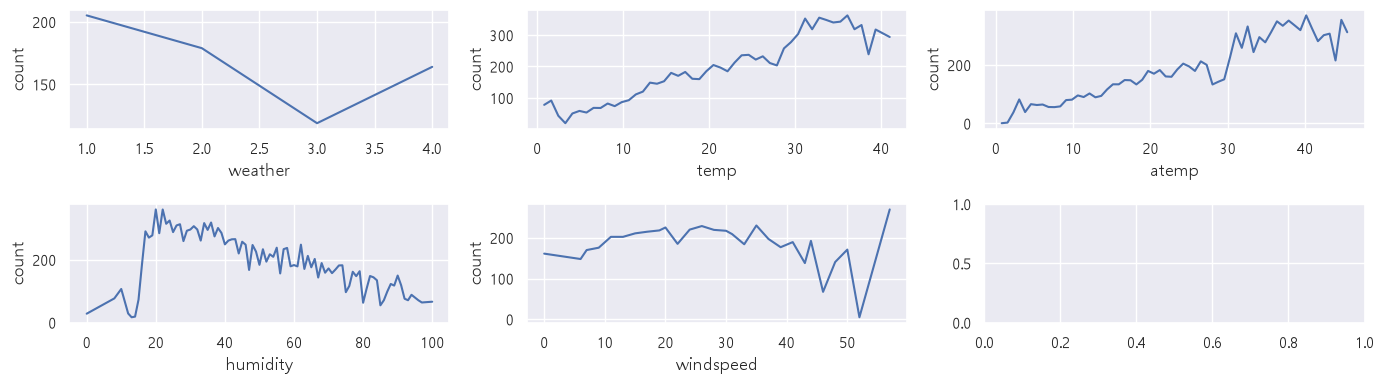

In [22]:
fig, axes = plt.subplots(2,3,     figsize=(14, 4)) 
col_list=['weather', 'temp', 'atemp','humidity', 'windspeed']

for i, col in enumerate(col_list) :
    줄=i//3
    칸=i%3
    sns.lineplot(x=col, y="count", data=train, errorbar=None, ax=axes[줄][칸])

plt.tight_layout()
plt.show()

### temp

* 시간별 온도/대여수 멀티 차트
* 라인:평균온도 / 막대(대여수)

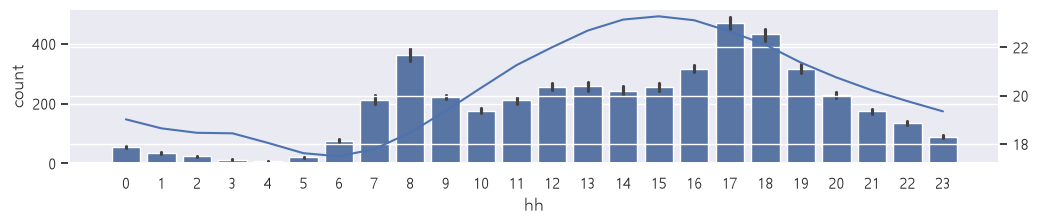

In [23]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="count", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['temp']].mean() )

plt.show()

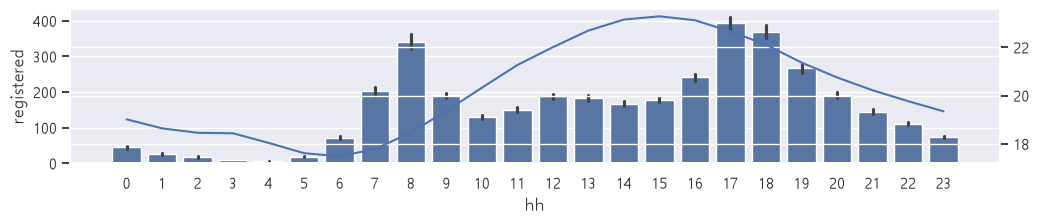

In [24]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="registered", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['temp']].mean() )

plt.show()

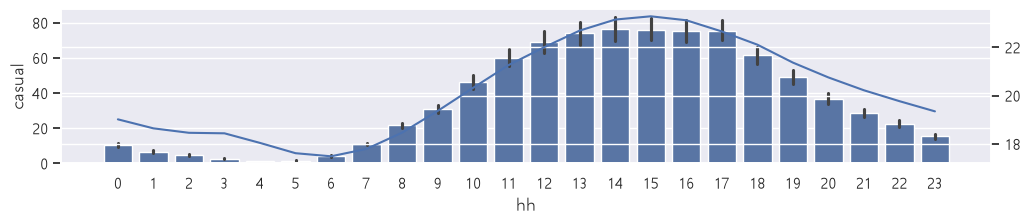

In [25]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="casual", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['temp']].mean() )

plt.show()

* <font color=red><b>현장 대여수(casual)는 온도(temp)만 보고도 예측 가능

### humidity
* 라인:습도평균 / 막대:대여수

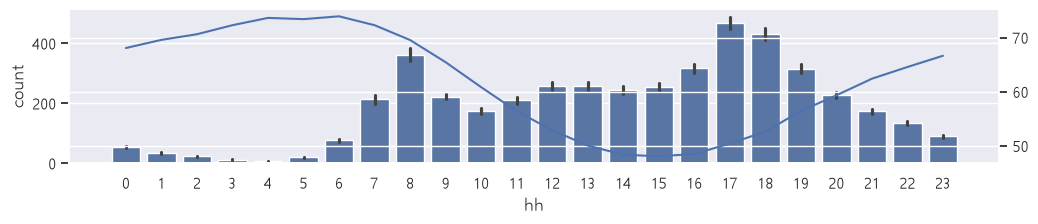

In [26]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="count", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['humidity']].mean() )

plt.show()

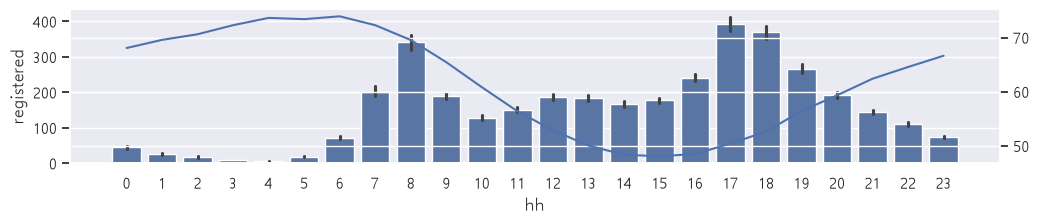

In [27]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="registered", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['humidity']].mean() )

plt.show()

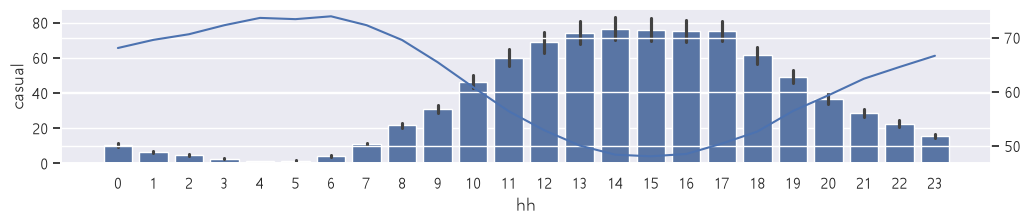

In [28]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="casual", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['humidity']].mean() )

plt.show()

### windspeed
* 라인:풍속평균 / 막대:대여수

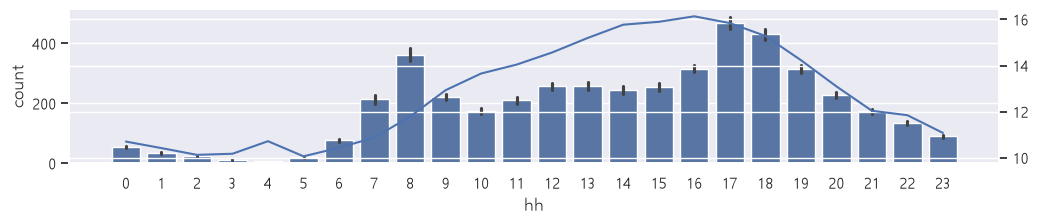

In [29]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="count", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['windspeed']].mean() )

plt.show()

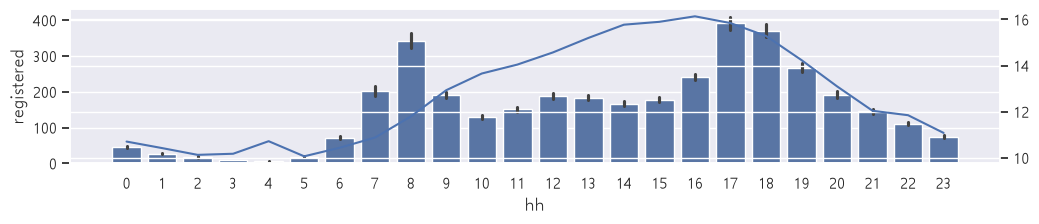

In [30]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="registered", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['windspeed']].mean() )

plt.show()

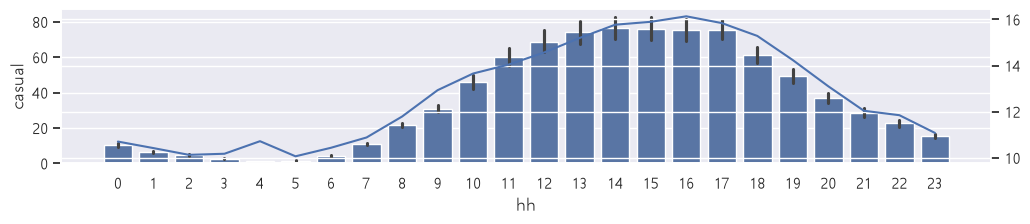

In [31]:
fig, axes = plt.subplots(figsize=(12,2))
sns.barplot(data=train, x="hh", y="casual", ax=axes)

axes2 = axes.twinx()
axes2.plot(train.groupby("hh")[['windspeed']].mean() )

plt.show()

* <font color=red><b>현장 대여수(casual)는 풍속(windspeed)만 보고도 예측 가능

### weather
* 라인: / 막대:대여수

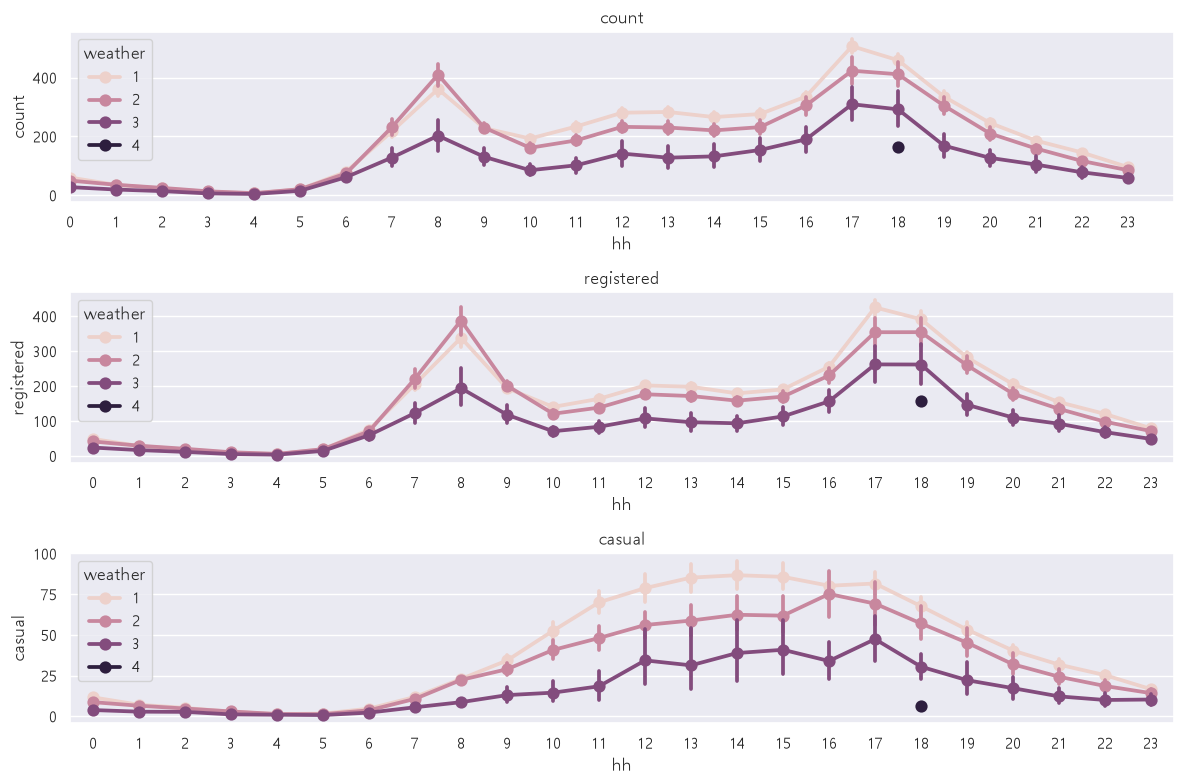

In [32]:
fig,ax = plt.subplots(nrows=3,ncols=1, figsize=(12,8))
sns.pointplot(data=train, x='hh', y='count'    , hue='weather', ax=ax[0])
ax[0].set(xlim=(0, 24))
ax[0].set(title="count")

sns.pointplot(data=train, x='hh', y='registered', hue='weather', ax=ax[1])
ax[1].set(title="registered")

sns.pointplot(data=train, x='hh', y='casual'    , hue='weather', ax=ax[2])
ax[2].set(title="casual")

plt.tight_layout()
plt.show()

* <font color=red><b>weather == 3 인경우 count 이상??

## 타켓 : 'count'(총), 'registered'(예약), 'casual'(현장)
* 범주형(0,1,2) 제외
* 연속형만 가공
* 일반적으로 target을 변환
* 로그변환은 추 후 원본 : log1p() --> expm1()

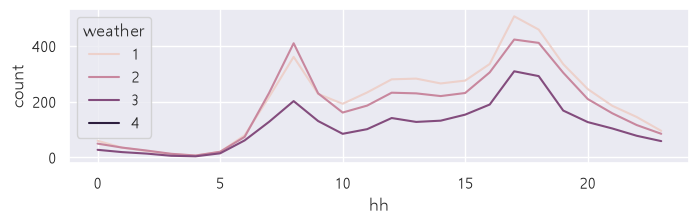

In [33]:
plt.figure(figsize=(8,2))
sns.lineplot(x='hh', y="count", hue="weather", data=train, errorbar=None)
plt.show()

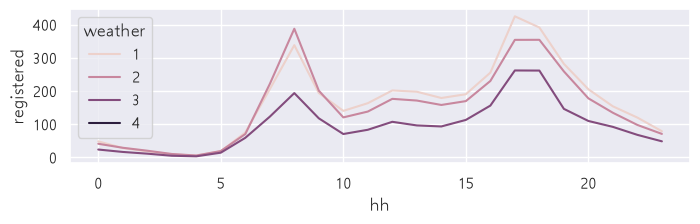

In [34]:
plt.figure(figsize=(8,2))
sns.lineplot(x='hh', y="registered", hue="weather", data=train, errorbar=None)
plt.show()

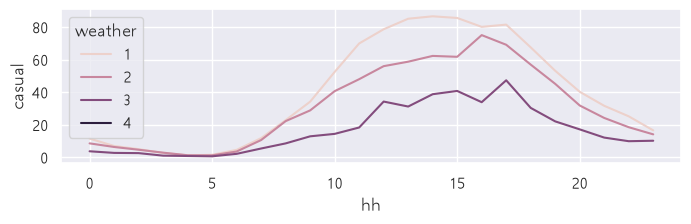

In [35]:
plt.figure(figsize=(8,2))
sns.lineplot(x='hh', y="casual", hue="weather", data=train, errorbar=None)
plt.show()

In [36]:
# train[ㅈ][ㅋ]
train[ train['weather']==4 ]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,dd,hh,week,woy
datetime,,,,,,,,,,,,,,,,,
2012-01-09 18:00:00,1,0,1,4,8.2,11.365,86,6.0032,6,158,164,2012,1,9,18,0,2


In [37]:
test[ test['weather']==4 ]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,dd,hh,week,woy
datetime,,,,,,,,,,,,,,
2011-01-26 16:00:00,1,0,1,4,9.02,9.85,93,22.0028,2011,1,26,16,2,4
2012-01-21 01:00:00,1,0,0,4,5.74,6.82,86,12.9980,2012,1,21,1,5,3


## 주말/휴일 관련
* 'holiday', 'workingday', 'week'

In [38]:
train[['holiday', 'workingday']].value_counts()

holiday  workingday
0        1             7436
         0             3163
1        0              287
Name: count, dtype: int64

In [39]:
train['day_type'] = 0
train.loc[  (train['holiday'] ==0) &  (train['workingday']==1) , 'day_type']  = 0     # 0

#holiday ==0  workingday==0
train.loc[  (train['holiday'] ==0) &  (train['workingday']==0) , 'day_type']  = 1     # 1

#holiday ==1  workingday==0
train.loc[  (train['holiday'] ==1) &  (train['workingday']==0) , 'day_type']  = 2      # 2

train['day_type'].value_counts()

day_type
0    7436
1    3163
2     287
Name: count, dtype: int64

In [40]:
test['day_type'] = 0
test.loc[  (test['holiday'] ==0) &  (test['workingday']==1) , 'day_type']  = 0     # 0

#holiday ==0  workingday==0
test.loc[  (test['holiday'] ==0) &  (test['workingday']==0) , 'day_type']  = 1     # 1

#holiday ==1  workingday==0
test.loc[  (test['holiday'] ==1) &  (test['workingday']==0) , 'day_type']  = 2      # 2

test['day_type'].value_counts()

day_type
0    4299
1    1803
2     391
Name: count, dtype: int64

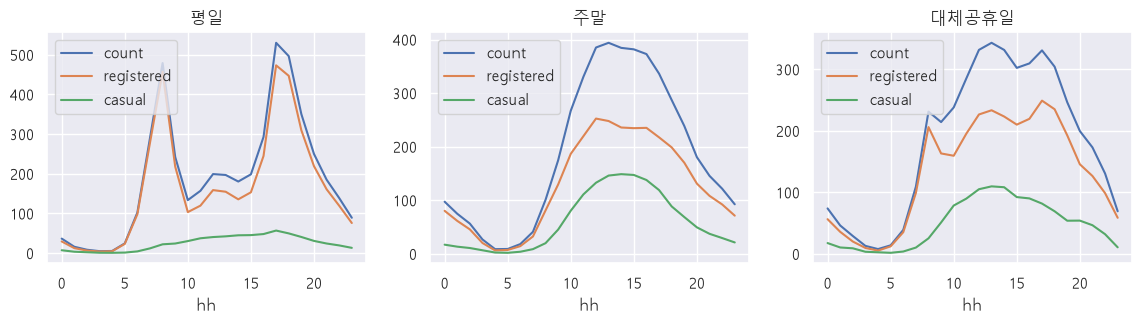

In [41]:
# plt.figure(figsize=(8,2))
# sns.lineplot(x='hh', y="count", hue="weather", data=train, errorbar=None)
# plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1,3,     figsize=(14, 3)) 

g0 = train[ train['day_type']==0 ].groupby('hh')[['count','registered','casual']].mean()
g0.plot(ax=ax1, title='평일') 

g1 = train[ train['day_type']==1 ].groupby('hh')[['count','registered','casual']].mean()
g1.plot(ax=ax2, title='주말') 

g2 = train[ train['day_type']==2 ].groupby('hh')[['count','registered','casual']].mean()
g2.plot(ax=ax3, title='대체공휴일') 

plt.show()


## 요일/월(파생피쳐) 별 대여수

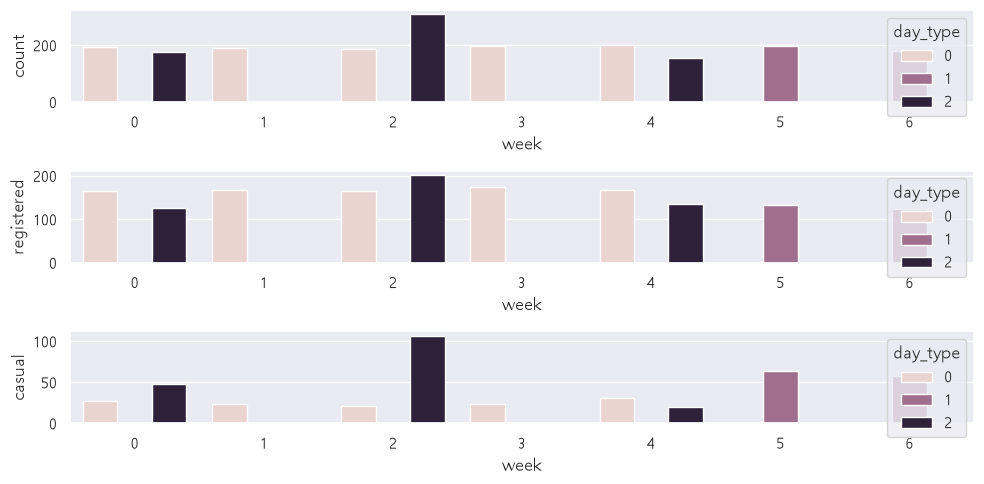

In [42]:
plt.figure(figsize=(10, 5)) 

plt.subplot(3,1,      1)         #---------------------------2행2열의 1번째
sns.barplot(x="week", y="count"     , hue="day_type", data=train, errorbar=None) 

plt.subplot(3,1,      2)         #---------------------------2행2열의 2번째
sns.barplot(x="week", y="registered", hue="day_type",data=train, errorbar=None) 

plt.subplot(3,1,      3)         #---------------------------2행2열의 3번째
sns.barplot(x="week", y="casual"    , hue="day_type", data=train, errorbar=None) 

plt.tight_layout()
plt.show()

* <FONT COLOR=RED><B>2012년 7월 4일 수요일: 미국 독립기념일 불꽃놀이 대규모 축제
* <FONT COLOR=RED><B>2012년 10월 22일 ~ 11월 2일 : 허리케인 샌디

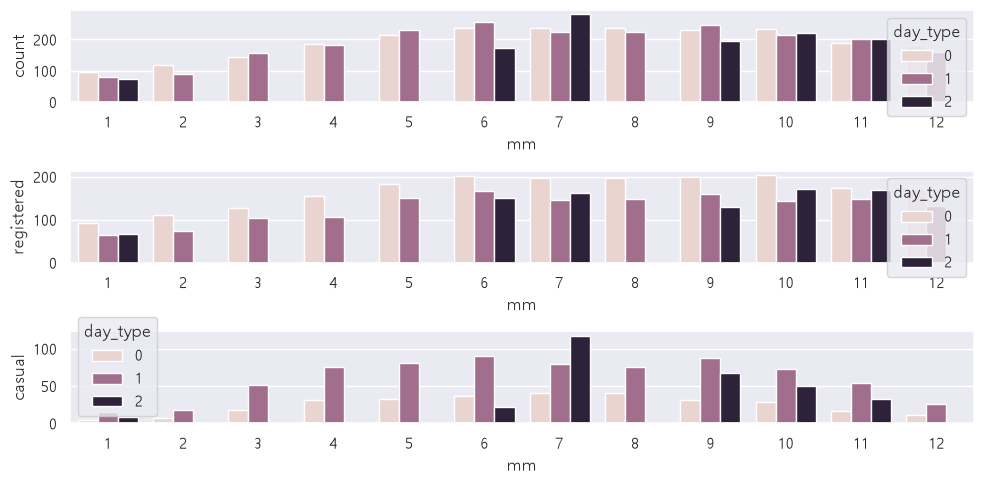

In [43]:
plt.figure(figsize=(10, 5)) 

plt.subplot(3,1,      1)         #---------------------------2행2열의 1번째
sns.barplot(x="mm", y="count"     , hue="day_type", data=train, errorbar=None) 

plt.subplot(3,1,      2)         #---------------------------2행2열의 2번째
sns.barplot(x="mm", y="registered", hue="day_type",data=train, errorbar=None) 

plt.subplot(3,1,      3)         #---------------------------2행2열의 3번째
sns.barplot(x="mm", y="casual"    , hue="day_type", data=train, errorbar=None) 

plt.tight_layout()
plt.show()

## 이상치(outlier)

### 박스플롯 시각화

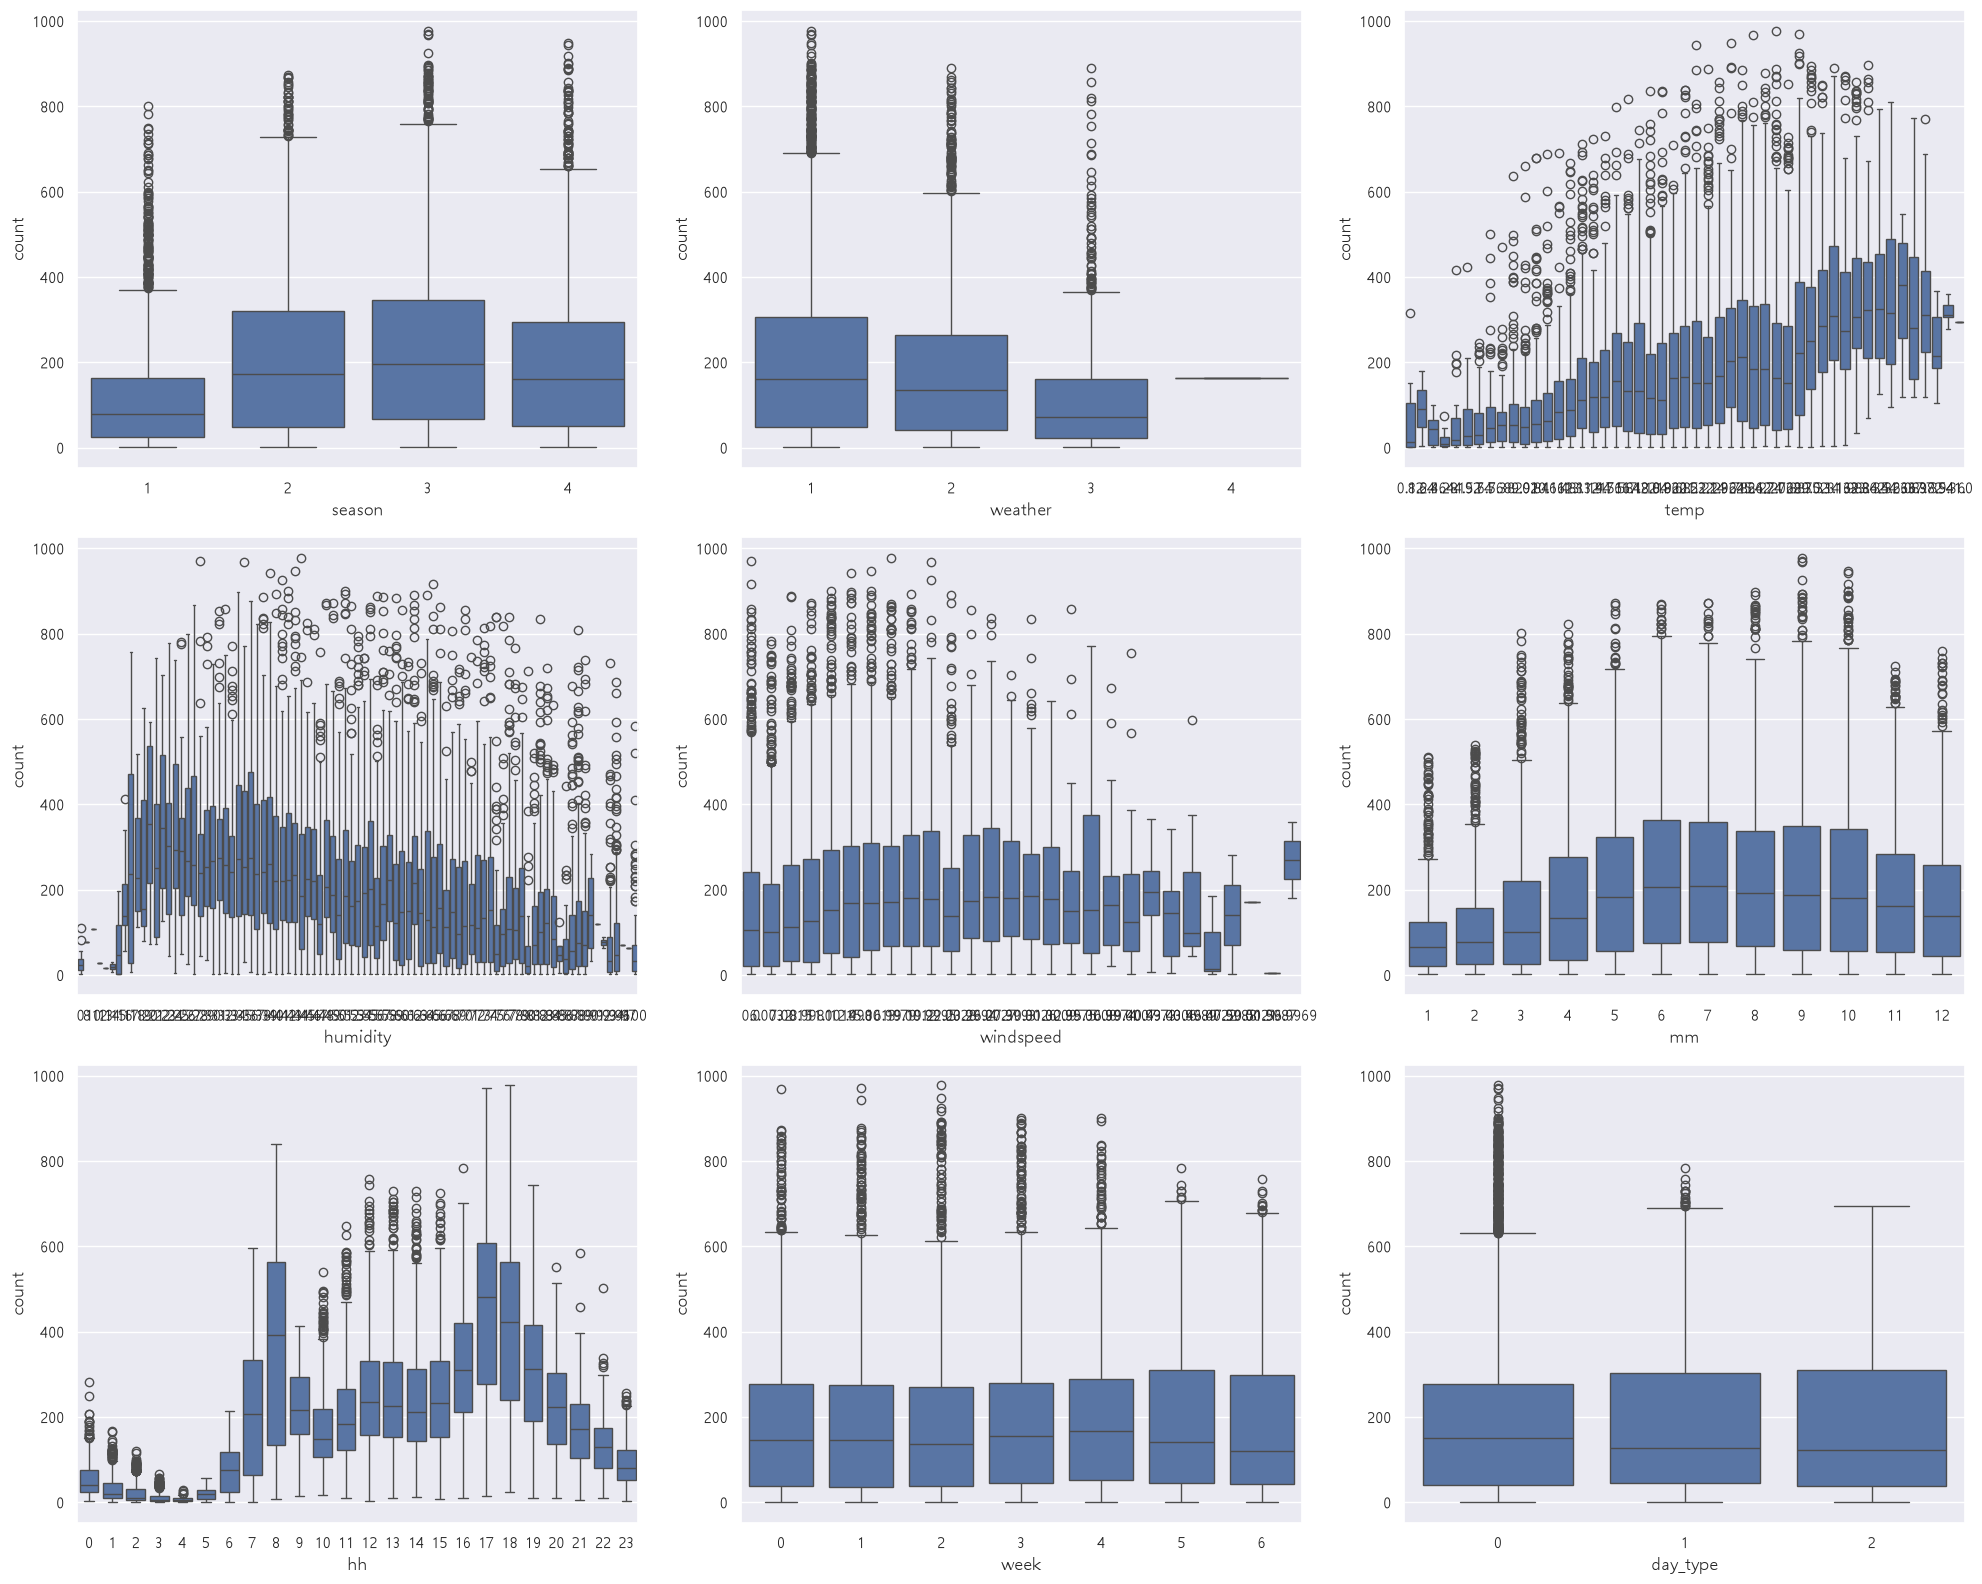

In [44]:
fig, axes = plt.subplots(3,3,     figsize=(20, 16)) 
col_list = ['season','weather', 'temp','humidity', 'windspeed', 'mm','hh', 'week', 'day_type']

for i, col in enumerate(col_list) :
    줄=i//3
    칸=i%3
    sns.boxplot(x=col, y="count", data=train,  ax=axes[줄][칸])

plt.tight_layout()
plt.show()


### 풍속 0 : 이상치
* 0.0000   :  1313건

In [45]:
train['windspeed'].value_counts()[:5]

windspeed
0.0000     1313
8.9981     1120
11.0014    1057
12.9980    1042
7.0015     1034
Name: count, dtype: int64

In [46]:
test['windspeed'].value_counts()[:5]

windspeed
0.0000     867
11.0014    638
8.9981     618
12.9980    615
7.0015     583
Name: count, dtype: int64

In [47]:
train[train['windspeed'] == 0].head(3)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,yy,mm,dd,hh,week,woy,day_type
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5,52,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5,52,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5,52,1


### 습도 < 2 : 이상치

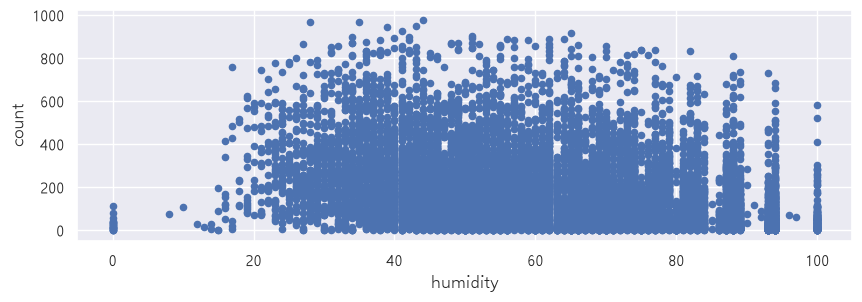

In [48]:
train.plot.scatter(x='humidity',y='count', figsize=(10, 3))
plt.show()

# **[3] 타겟 로그변환**
* 범주형(0,1,2) 제외
* 연속형만 가공
* 일반적으로 target을 변환
* 로그변환은 추 후 원본 : log1p() --> expm1()

In [49]:
train['count']      = np.log1p(train['count'])
train['registered'] = np.log1p(train['registered'])
train['casual']     = np.log1p(train['casual'])

In [ ]:
* MSE 
* MSLE 배율로 따진다. 로그를 왜 씌웠는가? 적은수 틀렸을때 페널티를 크게 주는것 모델을 정규화를 위해

# **[4] 공통함수**

$RMSLE = \sqrt{\frac{1}{n} \sum_{i=1}^n (\log(p_i + 1) - \log(a_i+1))^2 }$

```python 
sklearn.metrics.root_mean_squared_log_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')

## myscore222() 함수

In [50]:
def myscore222(df,  model_r=None, model_c=None, input_cols=[]) :    
    #X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, shuffle=False)
    #---7 : 3 분리
    train = df[df['dd'] <= 15]  #-----7
    val   = df[df['dd'] > 15]   #-----3(test) val 자체검증

    #-----------7 문제지, 답안지2
    train_X   = train[input_cols]
    train_y_r = train['registered'] #--로그변환된값
    train_y_c = train['casual']     #--로그변환된값
    
    #-----------3 문제지, 답안지2,self_test
    val_X   = val[input_cols]
    val_y_r = val['registered']     #--로그변환된값
    val_y_c = val['casual']         #--로그변환된값

    if model_r is None:
        model_r = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
    if model_c is None:
        model_c = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
    print(model_r.__class__.__name__)    
    print(model_c.__class__.__name__)    

    #------ registered 학습------
    model_r.fit(train_X, train_y_r)  # 학습 model_r.fit
    pred_r_log = model_r.predict(val_X)  #---로그변환된예측값
    pred_r = np.expm1(pred_r_log)        #----지수변환으로 원복 PRED_R
    
    #------ casual 학습------
    model_c.fit(train_X, train_y_c)
    pred_c_log = model_c.predict(val_X)  #---로그변환된예측값
    pred_c = np.expm1(pred_c_log)        #----지수변환으로 원복 PRED_C

    pred = np.round(pred_r + pred_c)     # r + c합치기  ---------------------------
    # 음수 예측값 처리 - log는 음수계산 못함 0으로 치환
    # pred[pred < 0] = 0
    pred = np.maximum(pred, 0)

    #------ 3 로그변환된 답안지 원복------
    y_test3 = np.expm1(val['registered']) + np.expm1(val['casual'])   # r + c
    
    rmsle = root_mean_squared_log_error(y_test3, pred)
    print( f"rmsle : {rmsle:.4f}" )
    return model_r, model_c

## 1차점수 : 우선 점수만 보자
* 0.3263

In [51]:
train.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'yy', 'mm',
       'dd', 'hh', 'week', 'woy', 'day_type'],
      dtype='str')

In [52]:
col_list = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed',  'yy', 'mm', 'hh', 'week', 'woy', 'day_type']
model_r, model_c = myscore222(train, model_r=None, model_c=None, input_cols=col_list)

RandomForestRegressor
RandomForestRegressor
rmsle : 0.3173


## mypred() 함수 : 공모전 test 예측

In [53]:
def mypred(test, model_r=None, model_c=None, MY_FNAME=None) :
    
    if model_r is None:
        model_r = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
    if model_c is None:
        model_c = RandomForestRegressor(
            n_estimators=100,
            random_state=1234
        )
    print(model_r.__class__.__name__)    
    print(model_c.__class__.__name__)    
    
    #------ registered 예측------
    pred_r_log = model_r.predict(test)   #---로그변환된예측값
    pred_r = np.expm1(pred_r_log)        #----지수변환으로 원복 PRED_R
    
    #------ casual 예측-----
    pred_c_log = model_c.predict(test)   #---로그변환된예측값
    pred_c = np.expm1(pred_c_log)        #----지수변환으로 원복 PRED_C
    
    pred = np.round(pred_r + pred_c)     # r + c합치기  ---------------------------
    # 음수 예측값 처리 - log는 음수계산 못함 0으로 치환
    # pred[pred < 0] = 0
    pred = np.maximum(pred, 0)
    
    if MY_FNAME is None:
        sub['count'] = pred
        sub.to_csv(MY_FNAME, index=False)
        
    return pred    

In [54]:
pred = mypred(test[col_list], model_r=model_r, model_c=model_c)  #, MY_FNAME="aaa.csv")
print(pred[:10])

RandomForestRegressor
RandomForestRegressor
[ 11.   6.   3.   2.   2.   4.  34.  83. 212. 128.]


# **[5]전처리 & 가공 : 풍속 채우기**

## windspeed 0 처리

* **[1] tt = train  + test 합치기**

In [55]:
train.shape, test.shape, train.columns

((10886, 18),
 (6493, 15),
 Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
        'humidity', 'windspeed', 'casual', 'registered', 'count', 'yy', 'mm',
        'dd', 'hh', 'week', 'woy', 'day_type'],
       dtype='str'))

In [56]:
print(train.shape, test.shape)

tt = pd.concat([train, test], axis=0)
print(tt.shape)

wdf = tt[["season","weather","humidity","mm","temp","yy","atemp","windspeed"]]
wdf.head(1)

(10886, 18) (6493, 15)
(17379, 18)


,season,weather,humidity,mm,temp,yy,atemp,windspeed
datetime,,,,,,,,
2011-01-01,1,1,81,1,9.84,2011,14.395,0.0


* **[2] train : windspped != 0 /   test = windspped == 0**

In [57]:
wdf[wdf['windspeed']==0].shape,   wdf[wdf['windspeed']!=0].shape

((2180, 8), (15199, 8))

In [58]:

wdf1 = wdf[wdf['windspeed']!=0]
wdf0 = wdf[wdf['windspeed']==0]

wdf1_train_X = wdf1.drop(columns=['windspeed'])
wdf1_train_y = wdf1['windspeed']

wdf0_test_X = wdf0.drop(columns=['windspeed'])
wdf0_test_y = wdf0['windspeed']  #-----------------여기가 풍속이 0 (여길 채워야 함)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=1234
)
rf.fit(wdf1_train_X, wdf1_train_y)
pred = rf.predict(wdf0_test_X)
print(pred[:10])

[6.892223   6.6594851  6.6594851  6.47689335 6.47689335 6.6594851
 6.717621   6.47689335 9.49474867 6.71964663]


* **시리즈에 넣기 : 가로 --> 세로 변형**

In [59]:
re_pred = pred.reshape(-1, 1)
re_pred[:10]

array([[6.892223  ],
       [6.6594851 ],
       [6.6594851 ],
       [6.47689335],
       [6.47689335],
       [6.6594851 ],
       [6.717621  ],
       [6.47689335],
       [9.49474867],
       [6.71964663]])

In [60]:
print( tt[tt['windspeed']==0].shape )
tt.loc[tt['windspeed']==0   , 'windspeed'] = re_pred
print( tt[tt['windspeed']==0].shape )

(2180, 18)
(0, 18)


In [61]:
train = tt[                : train.shape[0] ]
test  = tt[ train.shape[0] :                ]
test = test.drop(columns=['count','registered','casual'])

print( train[train['windspeed']==0].shape )
print( test[test['windspeed']==0].shape )

(0, 18)
(0, 15)


In [62]:
train.shape, test.shape 

((10886, 18), (6493, 15))

## 2차점수 : 풍속 채운 후 점수
* rmsle : 0.3263
* rmsle : 0.3244

In [63]:
model_r, model_c = myscore222(train, model_r=None, model_c=None, input_cols=col_list)

RandomForestRegressor
RandomForestRegressor
rmsle : 0.3153


## 학습 피쳐 중요도(feature_importances_)

* <b>트리모델 : model.feature_importances_

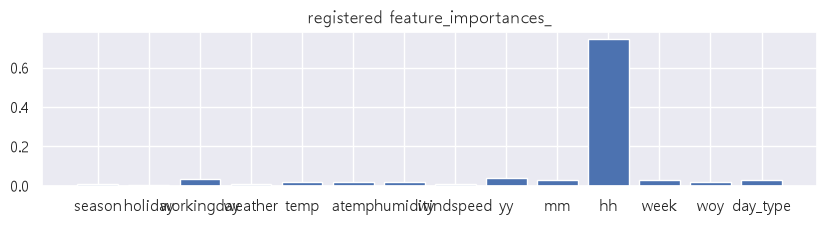

In [64]:
imp = model_r.feature_importances_

plt.figure(figsize=(10, 2)) 
plt.bar(train[col_list].columns, imp)
plt.title("registered feature_importances_")
plt.show()

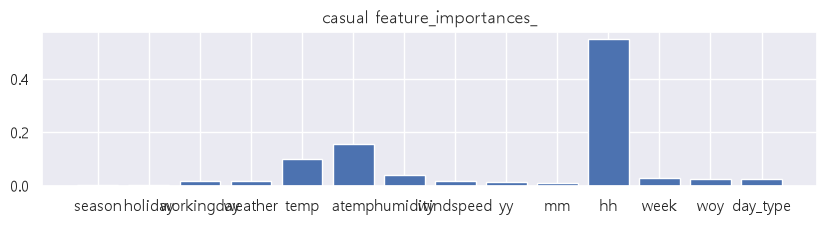

In [65]:
imp = model_c.feature_importances_

plt.figure(figsize=(10, 2)) 
plt.bar(train[col_list].columns, imp)
plt.title("casual feature_importances_")
plt.show()

# **[6]전처리 & 가공 : 파생피쳐**
* peak, ideal, sticky

In [66]:
for i, df in enumerate([train, test]):
    df['peak'] = df[['hh', 'workingday']].apply(
        lambda x: 1 if (
            (x['workingday'] == 1 and ( x['hh'] == 8 or 17 <= x['hh'] <= 18 or 12 <= x['hh'] <= 13))
            or
            (x['workingday'] == 0 and (10 <= x['hh'] <= 19) )
        ) else 0,
        axis=1
    )
    
    df['ideal'] = df[['temp', 'windspeed']].apply(
        lambda x: 1 if x['temp'] > 27 and x['windspeed'] < 30 else 0,
        axis=1
    )
    
    df['sticky'] = df[['humidity', 'workingday']].apply(
        lambda x: 1 if x['workingday'] == 1 and x['humidity'] >= 60 else 0,
        axis=1
    )
    
    if i == 0:
        train = df
    elif i == 1:
        test = df
        

In [67]:
test.head(1)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,dd,hh,week,woy,day_type,peak,ideal,sticky
datetime,,,,,,,,,,,,,,,,,,
2011-01-20,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0,3,3,0,0,0,0


# **[7]전처리 & 가공 : 습도 이상치 삭제**
* humidity < 2 : 22건 삭제

In [68]:
print(train.shape)
train = train.drop(train[train['humidity'] <= 2].index)
print(train.shape)

(10886, 21)
(10864, 21)


In [69]:
test[test['humidity'] <= 2]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,yy,mm,dd,hh,week,woy,day_type,peak,ideal,sticky
datetime,,,,,,,,,,,,,,,,,,


# **[8] 강력한 모델로 교체**
* 선형 보다는 트리 모델이 좋은 성능을 보임
* pip install xgboost , lightgbm
* <font color=red><b>sklearn 기본 모델 : GradientBoosting, RandomForest

## **GradientBoosting**
* Gradient Boosting(그래디언트 부스팅)은 여러 개의 단순하고 약한 예측 모델(주로 의사결정 트리)을 순차적으로 결합해 강력한 예측 성능을 만드는 앙상블(Ensemble) 학습 알고리즘

In [70]:
params = {
    'n_estimators': 150,
    'max_depth': 5,
    'random_state': 0,
    'min_samples_leaf': 10,
    'learning_rate': 0.1,
    'subsample': 0.7,
    'loss': 'squared_error'  #---ls
}
gbr_model = GradientBoostingRegressor(**params)
gbc_model = GradientBoostingRegressor(**params)

gbm_cols = [
    'weather', 'temp', 'humidity', 'windspeed',
    'holiday', 'workingday', 'season','hh', 'week', 'yy', 'ideal'
]

In [71]:
gb_r, gb_c = myscore222(train, model_r=gbr_model, model_c=gbc_model, input_cols=gbm_cols)

GradientBoostingRegressor
GradientBoostingRegressor
rmsle : 0.3104


## **RandomForest**
* 랜덤 포레스트(Random Forest)는 여러 개의 결정 트리(Decision Tree)를 모아 숲을 형성하고, 이들의 예측 결과를 종합하여 더 정확한 최종 결론을 내리는 앙상블(Ensemble) 머신러닝 알고리즘

In [72]:
params = {'n_estimators': 1000, 'max_depth': 15, 'random_state': 0, 'min_samples_split' : 5, 'n_jobs': -1}
rfr_model = RandomForestRegressor(**params)
rfc_model = RandomForestRegressor(**params)

rf_cols = ['weather', 'temp', 'windspeed',
    'workingday', 'season', 'holiday', 'sticky','hh', 'week', 'woy', 'peak']

In [73]:
rf_r, rf_c = myscore222(train, model_r=rfr_model, model_c=rfc_model, input_cols=rf_cols)

RandomForestRegressor
RandomForestRegressor
rmsle : 0.4340


# **[9] 공모전 test : casual + registered**
* 각각 예측해서 합산

In [74]:
gbm_pred = mypred(test[gbm_cols], model_r=gb_r, model_c=gb_c, MY_FNAME=None) 

rf_pred  = mypred(test[rf_cols], model_r=rf_r, model_c=rf_c, MY_FNAME=None) 

final_pred = np.round(.20*rf_pred + .80*gbm_pred)

GradientBoostingRegressor
GradientBoostingRegressor
RandomForestRegressor
RandomForestRegressor


In [75]:
sub['count'] = final_pred
sub.to_csv("lec11_final.csv", index=False)

# **15위 / 3244 : global top 0.4%**

In [76]:
(15 / 3244) * 100 

0.4623921085080148

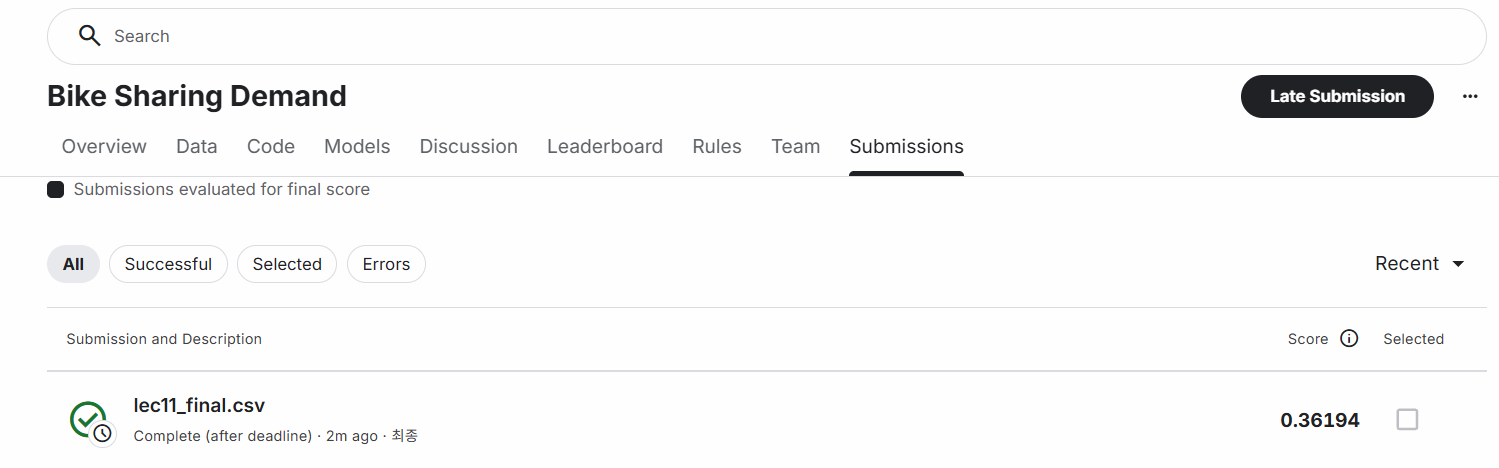

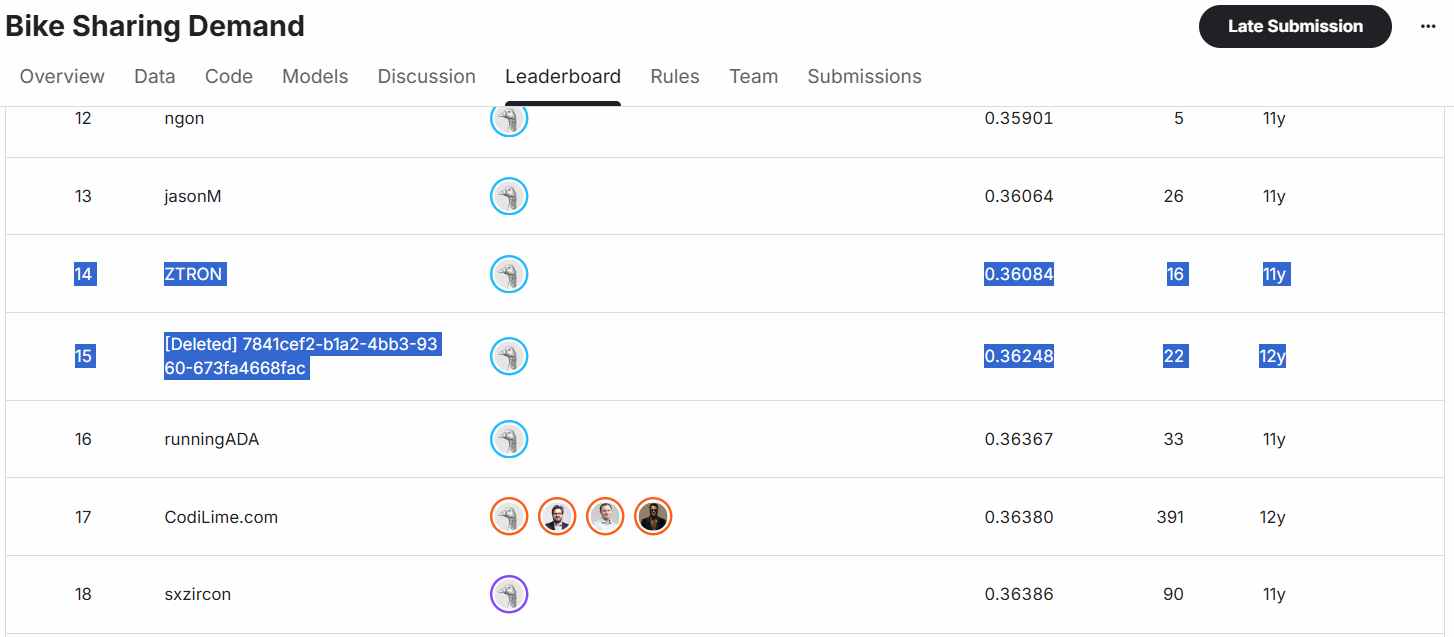